X_train: (4072076, 13)  X_val: (1018020, 13)
Train fraud rate: 0.0012951624674981507
scale_pos_weight: 771.1039059537353
[0]	validation_0-auc:0.99915
[10]	validation_0-auc:0.99935
[20]	validation_0-auc:0.99937
[30]	validation_0-auc:0.99939
[40]	validation_0-auc:0.99957
[50]	validation_0-auc:0.99971
[60]	validation_0-auc:0.99976
[70]	validation_0-auc:0.99980
[80]	validation_0-auc:0.99983
[90]	validation_0-auc:0.99982
[100]	validation_0-auc:0.99983
[110]	validation_0-auc:0.99980
[115]	validation_0-auc:0.99979

Best iteration: 95

XGBoost Evaluation on X_val
accuracy: 0.9999
precision: 0.9434
recall: 0.9977
f1: 0.9698
auc_roc: 0.9998

Confusion Matrix:
 [[1016622      79]
 [      3    1316]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1016701
           1       0.94      1.00      0.97      1319

    accuracy                           1.00   1018020
   macro avg       0.97      1.00      0.98   1018020
weigh

<Figure size 1000x600 with 0 Axes>

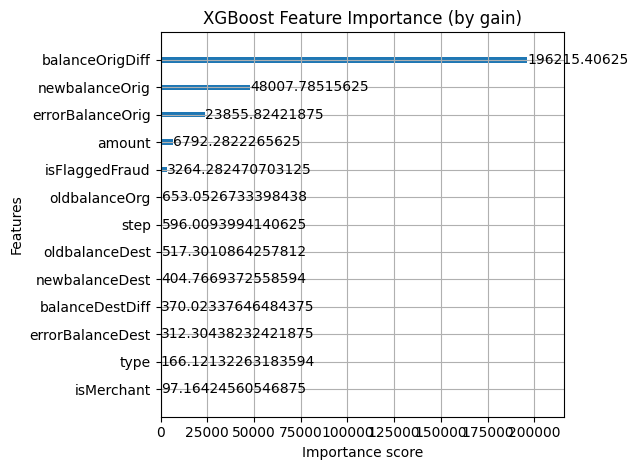

In [ ]:
"""
XGBoost training for PaySim fraud detection.
Matches folder structure:
ml/dataset/processed/  -> input data
ml/models/              -> saved model + plots
ml/reports/             -> metrics for final report

Run this from inside the ml/ folder (or adjust the paths below).
"""

import pandas as pd
import joblib
import json
import os
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)


# 0. Make sure output folders exist

os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)


# 1. Load preprocessed data

X_train = pd.read_csv("../dataset/processed/X_train.csv")
y_train = pd.read_csv("../dataset/processed/y_train.csv").values.ravel()
X_val = pd.read_csv("../dataset/processed/X_val.csv")
y_val = pd.read_csv("../dataset/processed/y_val.csv").values.ravel()

print("X_train:", X_train.shape, " X_val:", X_val.shape)
print("Train fraud rate:", y_train.mean())


# 2. Handle class imbalance

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)


# 3. Train XGBoost with early stopping

model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=10
)

print("\nBest iteration:", model.best_iteration)


# 4. Evaluate on validation set

y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_val, y_pred),
    "precision": precision_score(y_val, y_pred),
    "recall": recall_score(y_val, y_pred),
    "f1": f1_score(y_val, y_pred),
    "auc_roc": roc_auc_score(y_val, y_proba),
}

print("\n" + "=" * 60)
print("XGBoost Evaluation on X_val")
print("=" * 60)
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred, zero_division=0))


# 5. Feature importance

plt.figure(figsize=(10, 6))
plot_importance(model, max_num_features=13, importance_type="gain")
plt.title("XGBoost Feature Importance (by gain)")
plt.tight_layout()
plt.savefig("models/xgboost_feature_importance.png")
print("\nFeature importance plot saved to models/xgboost_feature_importance.png")


# 6. Save model + metrics report

joblib.dump(model, "../models/xgboost_model.joblib")

with open("reports/xgboost_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("\nModel saved to models/xgboost_model.joblib")
print("Metrics saved to reports/xgboost_metrics.json")
print("\nNext: evaluate this same model on X_test/y_test ONCE as your final reported result.")